# Résumé
#### Dans ce notebook on fera le nettoyage du jeu de données et un peu d'ingénerie de caractéristiques, le but est de rendre exploitable le dataset pour ensuite appliquer les méthodes de clustering et réduction de dimensions

Les données nettoyées se situeront dans `...\racine du repo\data\clean`
Voici une explication du nettoyage que nous ferons :


Tout d'abord on a vu que plusieurs caractéristiques possèdent énormément de NaN (plus de 50% dans plusieurs cas) on va donc supprimer immédiatement les colonnes qu'on considère inutilisables (>60%) et pour les autres on va devoir établir une stratégie pour remplacer les NaN (voici des exemples : remplacer par le mode/médiane/..., supprimer les lignes avec un NaN, créer une catégorie "inconnu")

 - Supprimer les colonnes redondantes, par exemple : `LOC_X` et `LOC_Y` sont simplement la même chose que `LOC_LONG` et `LOC_LAT`, il n'y a aucun intérêt à garder les deux.
 - Encoder les dates et heures en des variables utilisables
 - One-hot encode les variables catégorielles, en fait toutes les variables qui commencent par `CD` sont catégorielles et lorsqu'on a utilisé .info on voit que ce sont presque tous des float64 ce qui est problématique
 - Regrouper les classes de gravité en 3 niveaux pour faciliter la classification

In [1]:
import sys

# add root path, to import all modules
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.accidents.data import fetch_collisions, run_full_pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

#### Pour voir la logique du nettoyage, c'est tout implémenté dans data_cleaning.py 

In [2]:
path = fetch_collisions(raw_dir='data/raw', force=False)

df = run_full_pipeline(csv_path=path, save_dir='../data/clean')

Fichier deja present : C:\Users\Pierre Emery\Documents\Projets\bixi\data\raw\collisions_routieres.csv
On commence le nettoyage

Données chargées : 218,272 lignes × 68 colonnes

18 colonnes supprimées, 50 colonnes restantes
Colonnes créées : MOIS, SAISON, HEURE
HEURE : 17245 NaN (7.90%)
MOIS  : 0 NaN (0.00%)
Colonnes supprimées : DT_ACCDN, HEURE_ACCDN
9 colonnes CD_* converties en catégoriel (string)
11 lignes supprimées (coordonnées manquantes)
CD_GENRE_ACCDN : 10066 NaN changé en 'Inconnu'
CD_ETAT_SURFC : 12760 NaN changé en 'Inconnu'
CD_ECLRM : 12919 NaN changé en 'Inconnu'
CD_ENVRN_ACCDN : 7055 NaN changé en 'Inconnu'
CD_CATEG_ROUTE : 6354 NaN changé en 'Inconnu'
CD_ASPCT_ROUTE : 9917 NaN changé en 'Inconnu'
CD_LOCLN_ACCDN : 17763 NaN changé en 'Inconnu'
CD_CONFG_ROUTE : 21972 NaN changé en 'Inconnu'
CD_COND_METEO : 13602 NaN changé en 'Inconnu'
REG_ADM : 8 NaN changé en 'Inconnu'
MRC : 8 NaN changé en 'Inconnu'
LOC_DETACHEE : 19 NaN changé en 'Inconnu'
NaN restants (normaux, seront

# On refait une petite exploration pour comaprer 

In [3]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 217956 entries, 0 to 217955
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   JR_SEMN_ACCDN                217956 non-null  str    
 1   CD_GENRE_ACCDN               217956 non-null  str    
 2   CD_ETAT_SURFC                217956 non-null  str    
 3   CD_ECLRM                     217956 non-null  str    
 4   CD_ENVRN_ACCDN               217956 non-null  str    
 5   CD_CATEG_ROUTE               217956 non-null  str    
 6   CD_ASPCT_ROUTE               217956 non-null  str    
 7   CD_LOCLN_ACCDN               217956 non-null  str    
 8   CD_CONFG_ROUTE               217956 non-null  str    
 9   CD_COND_METEO                217956 non-null  str    
 10  NB_VEH_IMPLIQUES_ACCDN       217956 non-null  int64  
 11  NB_MORTS                     217956 non-null  int64  
 12  NB_BLESSES_GRAVES            217956 non-null  int64  
 13  NB_BLESSES

# Suppression de variables
On note bien que pour certaines variables comme le nombre de morts par exemple, ça serait tricher de les utiliser pour la classification, dans le sens que le modèle apprendra trop facilement que si le nombre de morts est plus grand que 0 c'est un accident Grave. Mais on ne jette pas ces variables dans le cleaning parce qu'elles pourraient quand même être utile pour le clustering.

In [4]:
df.head()

,JR_SEMN_ACCDN,CD_GENRE_ACCDN,CD_ETAT_SURFC,CD_ECLRM,CD_ENVRN_ACCDN,CD_CATEG_ROUTE,CD_ASPCT_ROUTE,CD_LOCLN_ACCDN,CD_CONFG_ROUTE,CD_COND_METEO,...,LOC_COTE_QD,LOC_COTE_PD,LOC_DETACHEE,LOC_IMPRECISION,LOC_LONG,LOC_LAT,MOIS,SAISON,HEURE,GRAVITE_3
0,ME,31,16,1,1,21,11,33,4,11,...,A,3,O,N,-73.861616,45.455505,2,Hiver,NaN,Materiel
1,MA,31,11,Inconnu,Inconnu,Inconnu,Inconnu,Inconnu,Inconnu,11,...,B,4,N,N,-73.878549,45.486871,1,Hiver,NaN,Materiel
2,VE,31,11,3,3,13,21,32,1,11,...,A,1,N,O,-73.871542,45.490564,2,Hiver,2.0,Materiel
3,JE,31,11,1,3,21,11,40,2,11,...,A,1,O,N,-73.804841,45.484648,10,Automne,15.0,Materiel
4,DI,31,12,1,3,21,11,40,Inconnu,12,...,A,1,O,N,-73.543590,45.467136,4,Printemps,15.0,Materiel


In [5]:
df.describe()

,NB_VEH_IMPLIQUES_ACCDN,NB_MORTS,NB_BLESSES_GRAVES,NB_BLESSES_LEGERS,AN,NB_VICTIMES_TOTAL,nb_automobile_camion_leger,nb_camionLourd_tractRoutier,nb_outil_equipement,nb_tous_autobus_minibus,...,NB_VICTIMES_MOTO,NB_DECES_VELO,NB_BLESSES_VELO,NB_VICTIMES_VELO,VITESSE_AUTOR,LOC_COTE_PD,LOC_LONG,LOC_LAT,MOIS,HEURE
count,217956.000000,217956.000000,217956.000000,217956.000000,217956.000000,217956.000000,217956.000000,217956.000000,217956.000000,217956.000000,...,217956.000000,217956.000000,217956.000000,217956.000000,137232.000000,217956.000000,217956.000000,217956.000000,217956.000000,200782.000000
mean,1.950288,0.001234,0.008933,0.260323,2015.824584,0.270490,1.486286,0.103356,0.014452,0.025909,...,0.008034,0.000142,0.030061,0.030203,45.462429,1.207299,-73.622547,45.526697,6.508493,13.140272
std,0.584281,0.035885,0.102449,0.571186,2.823877,0.582605,0.784160,0.316440,0.119807,0.161015,...,0.093537,0.011925,0.171720,0.172109,8.717839,0.586552,0.077734,0.053790,3.510793,5.490334
min,1.000000,0.000000,0.000000,0.000000,2012.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-73.970506,45.402674,1.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,2013.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,40.000000,1.000000,-73.646161,45.489357,3.000000,9.000000
50%,2.000000,0.000000,0.000000,0.000000,2016.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,50.000000,1.000000,-73.607108,45.524415,7.000000,14.000000
75%,2.000000,0.000000,0.000000,0.000000,2018.000000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,50.000000,1.000000,-73.571695,45.562558,10.000000,17.000000
max,31.000000,2.000000,6.000000,24.000000,2021.000000,27.000000,30.000000,3.000000,2.000000,3.000000,...,3.000000,1.000000,2.000000,2.000000,100.000000,4.000000,-73.479864,45.702491,12.000000,23.000000


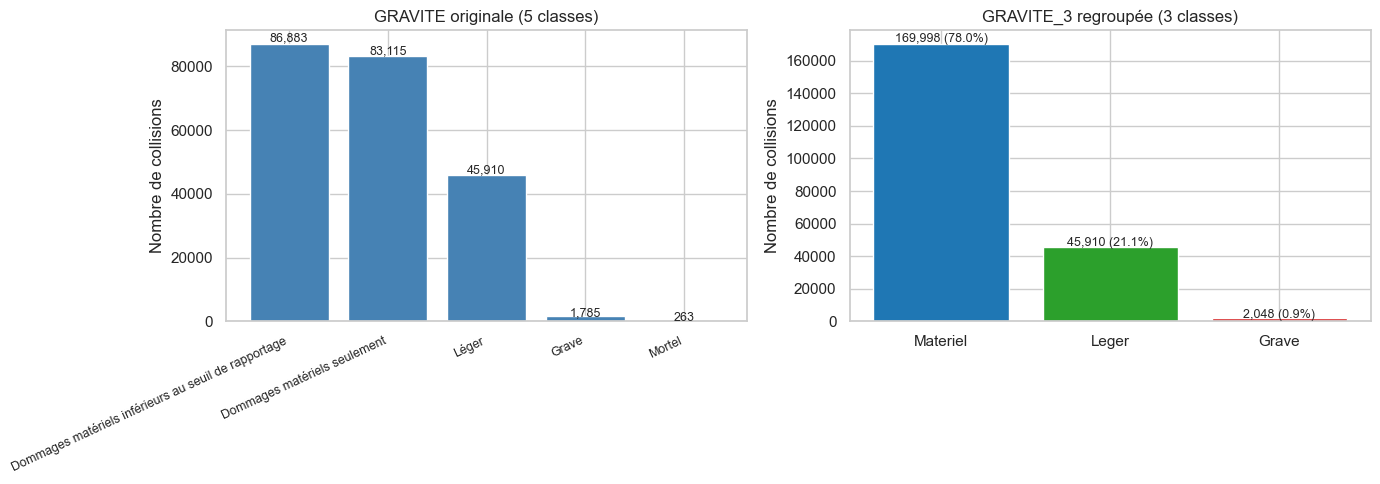

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GRAVITE originale (5 classes)
counts_5 = df['GRAVITE'].value_counts()
axes[0].bar(range(len(counts_5)), counts_5.values, color='steelblue')
axes[0].set_xticks(range(len(counts_5)))
axes[0].set_xticklabels(counts_5.index, rotation=25, ha='right', fontsize=9)
axes[0].set_title('GRAVITE originale (5 classes)')
axes[0].set_ylabel('Nombre de collisions')
for i, v in enumerate(counts_5.values):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

# GRAVITE_3 regroupée (3 classes)
counts_3 = df['GRAVITE_3'].value_counts()
colors_3 = ['#1f77b4', '#2ca02c', '#d62728']
axes[1].bar(counts_3.index, counts_3.values, color=colors_3[:len(counts_3)])
axes[1].set_title('GRAVITE_3 regroupée (3 classes)')
axes[1].set_ylabel('Nombre de collisions')
for i, (cat, v) in enumerate(counts_3.items()):
    pct = v / len(df) * 100
    axes[1].text(i, v * 1.01, f'{v:,} ({pct:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

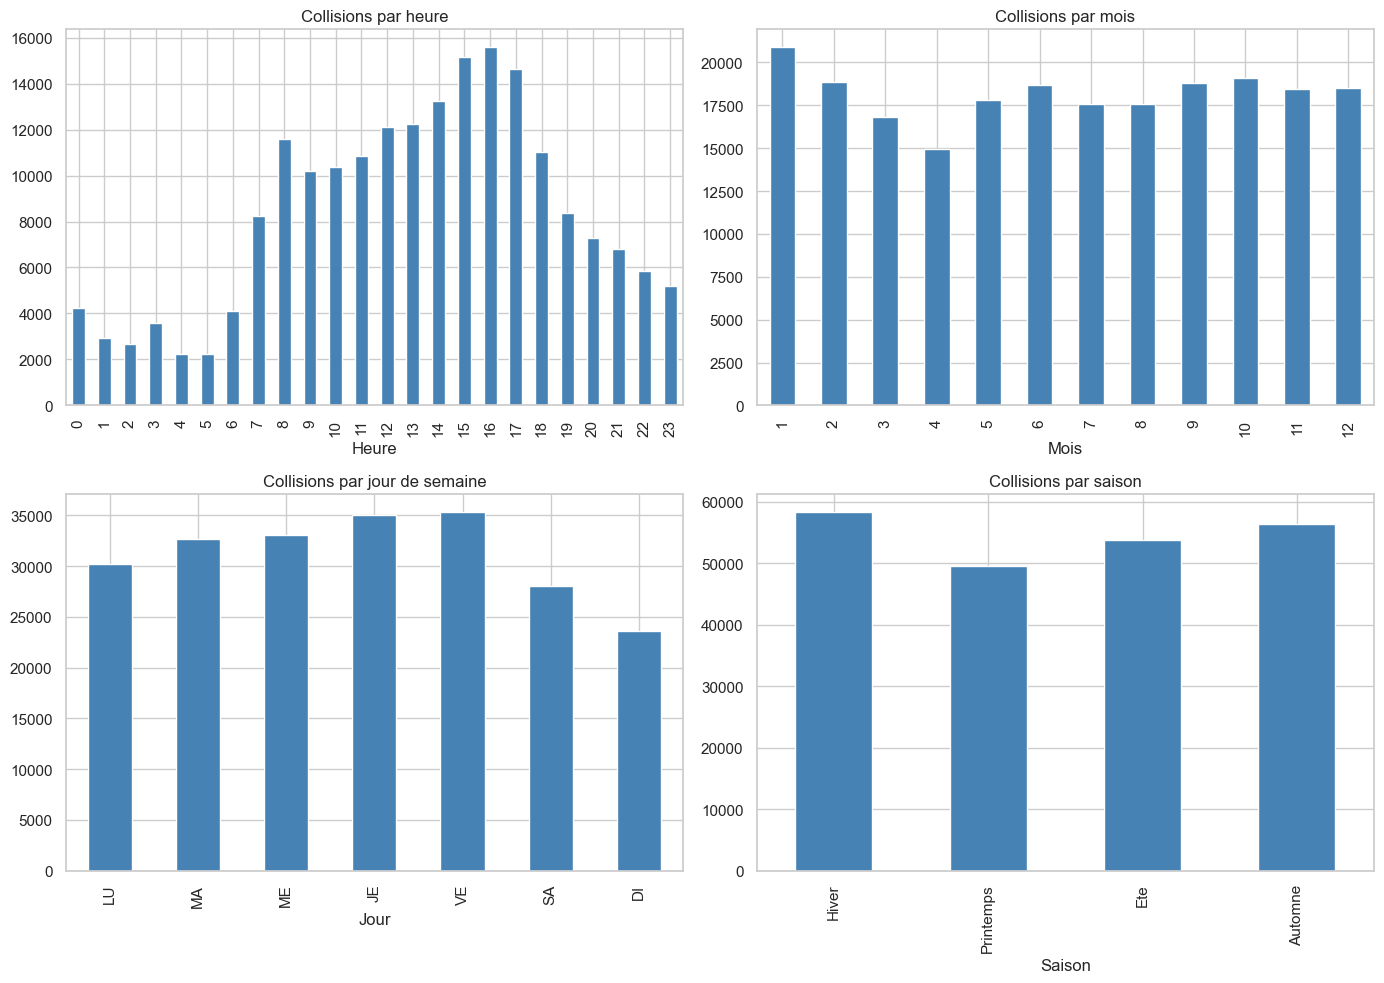

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Par heure (on exclut les NaN)
df['HEURE'].dropna().astype(int).value_counts().sort_index().plot.bar(
    ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Collisions par heure')
axes[0, 0].set_xlabel('Heure')

# Par mois
df['MOIS'].dropna().astype(int).value_counts().sort_index().plot.bar(
    ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Collisions par mois')
axes[0, 1].set_xlabel('Mois')

# Par jour de semaine (probablement deja sans NaN grace a "Inconnu")
jour_order = ['LU', 'MA', 'ME', 'JE', 'VE', 'SA', 'DI']
jour_counts = df['JR_SEMN_ACCDN'].value_counts().reindex(jour_order)
jour_counts.plot.bar(ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('Collisions par jour de semaine')
axes[1, 0].set_xlabel('Jour')

# Par saison
saison_order = ['Hiver', 'Printemps', 'Ete', 'Automne']
saison_counts = df['SAISON'].value_counts().reindex(saison_order)
saison_counts.plot.bar(ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Collisions par saison')
axes[1, 1].set_xlabel('Saison')

plt.tight_layout()
plt.show()

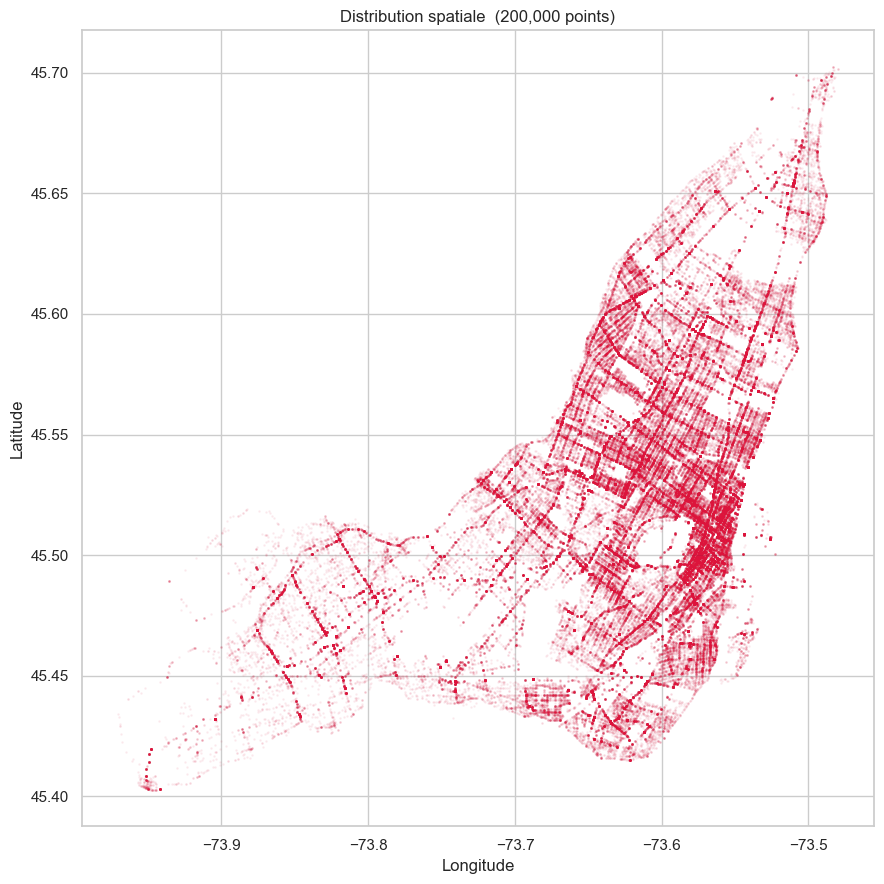

In [8]:
sample = df.sample(min(200_000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(sample['LOC_LONG'], sample['LOC_LAT'], alpha=0.05, s=1, color='crimson')
ax.set_title(f'Distribution spatiale  ({len(sample):,} points)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Ici c'est bien d'ouvrir le dictionnaire https://donnees.montreal.ca/dataset/cd722e22-376b-4b89-9bc2-7c7ab317ef6b/resource/f69c656e-9c0c-4763-bb5b-33e5ca46713c/download/rapports-accident-documentation.pdf pour voir ce que les nombres encodent

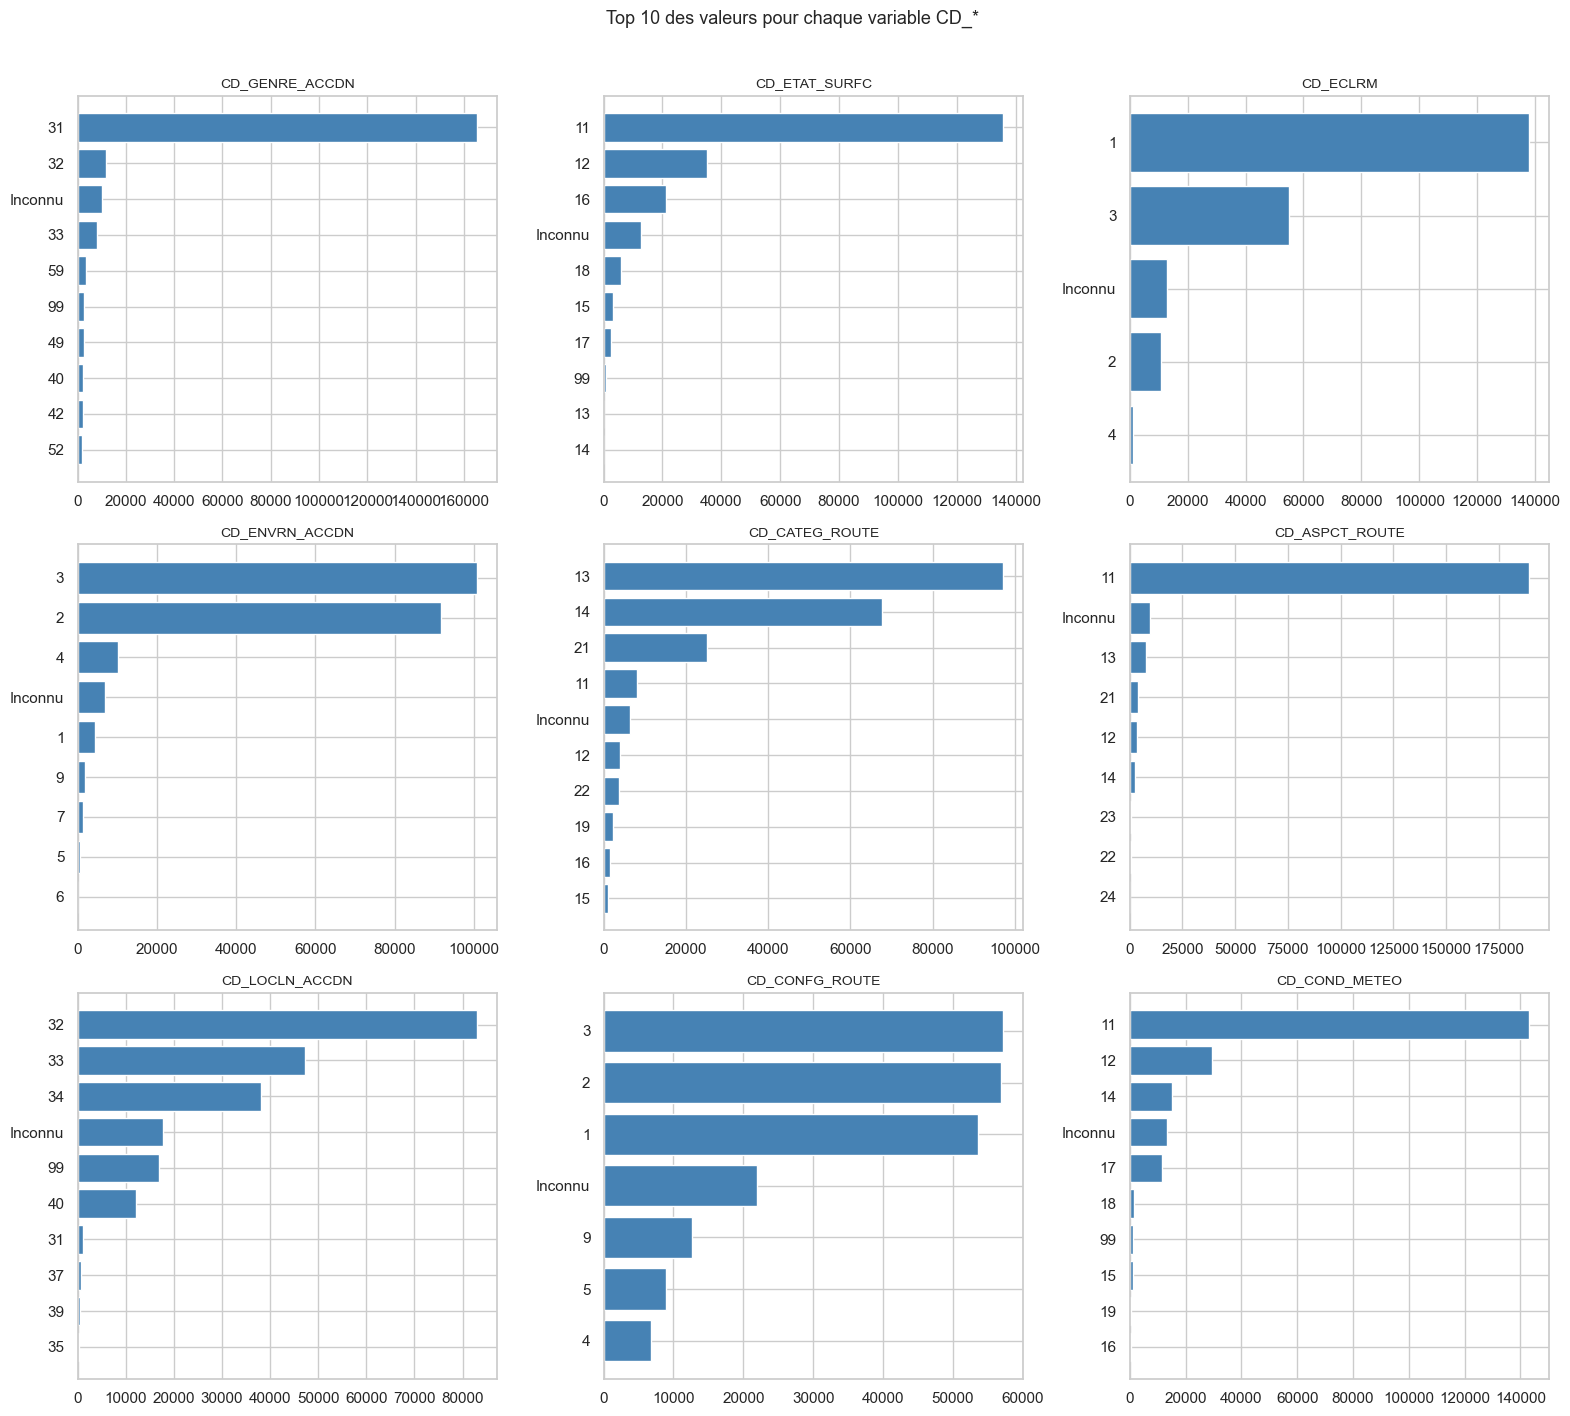

In [9]:
cols_cd = [c for c in df.columns if c.startswith('CD_')]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_cd):
    counts = df[col].value_counts().head(10)
    axes[i].barh(counts.index.astype(str), counts.values, color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].invert_yaxis()

# Cacher les axes inutilisés
for j in range(len(cols_cd), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 des valeurs pour chaque variable CD_*', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

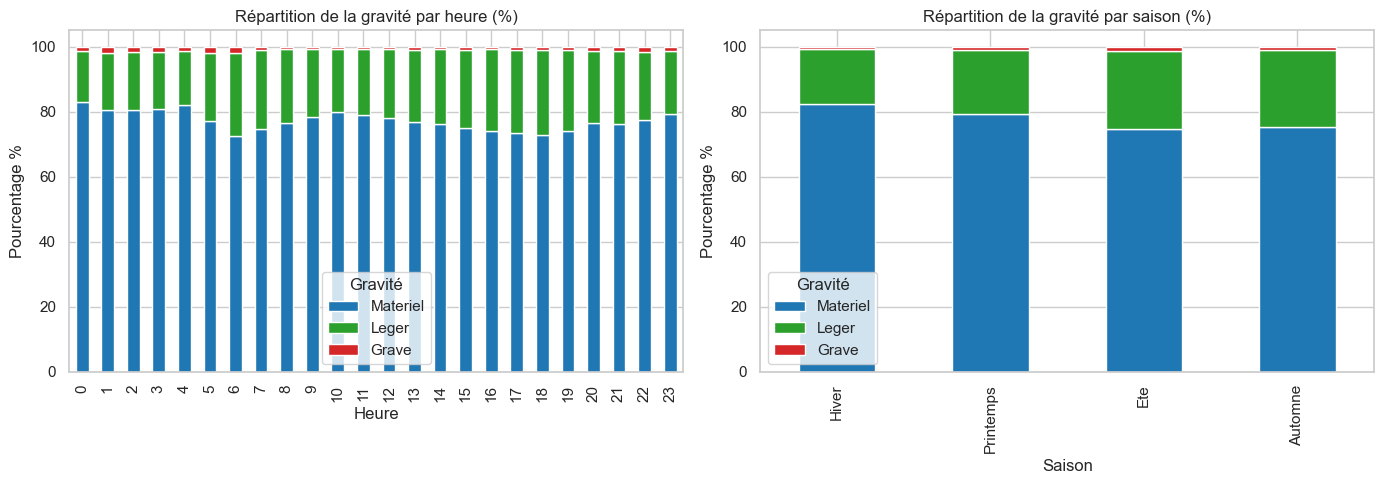

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gravité par heure (on exclut les NaN de HEURE)
df_heure = df.dropna(subset=['HEURE'])
ct_heure = pd.crosstab(df_heure['HEURE'].astype(int), df_heure['GRAVITE_3'], normalize='index') * 100
ct_heure[['Materiel', 'Leger', 'Grave']].plot.bar(stacked=True, ax=axes[0], 
    color=['#1f77b4', '#2ca02c', '#d62728'])
axes[0].set_title('Répartition de la gravité par heure (%)')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Pourcentage %')
axes[0].legend(title='Gravité')

# Gravité par saison 
ct_saison = pd.crosstab(df['SAISON'], df['GRAVITE_3'], normalize='index') * 100
ct_saison = ct_saison.reindex(['Hiver', 'Printemps', 'Ete', 'Automne'])
ct_saison[['Materiel', 'Leger', 'Grave']].plot.bar(stacked=True, ax=axes[1],
    color=['#1f77b4', '#2ca02c', '#d62728'])
axes[1].set_title('Répartition de la gravité par saison (%)')
axes[1].set_xlabel('Saison')
axes[1].set_ylabel('Pourcentage %')
axes[1].legend(title='Gravité')

plt.tight_layout()
plt.show()

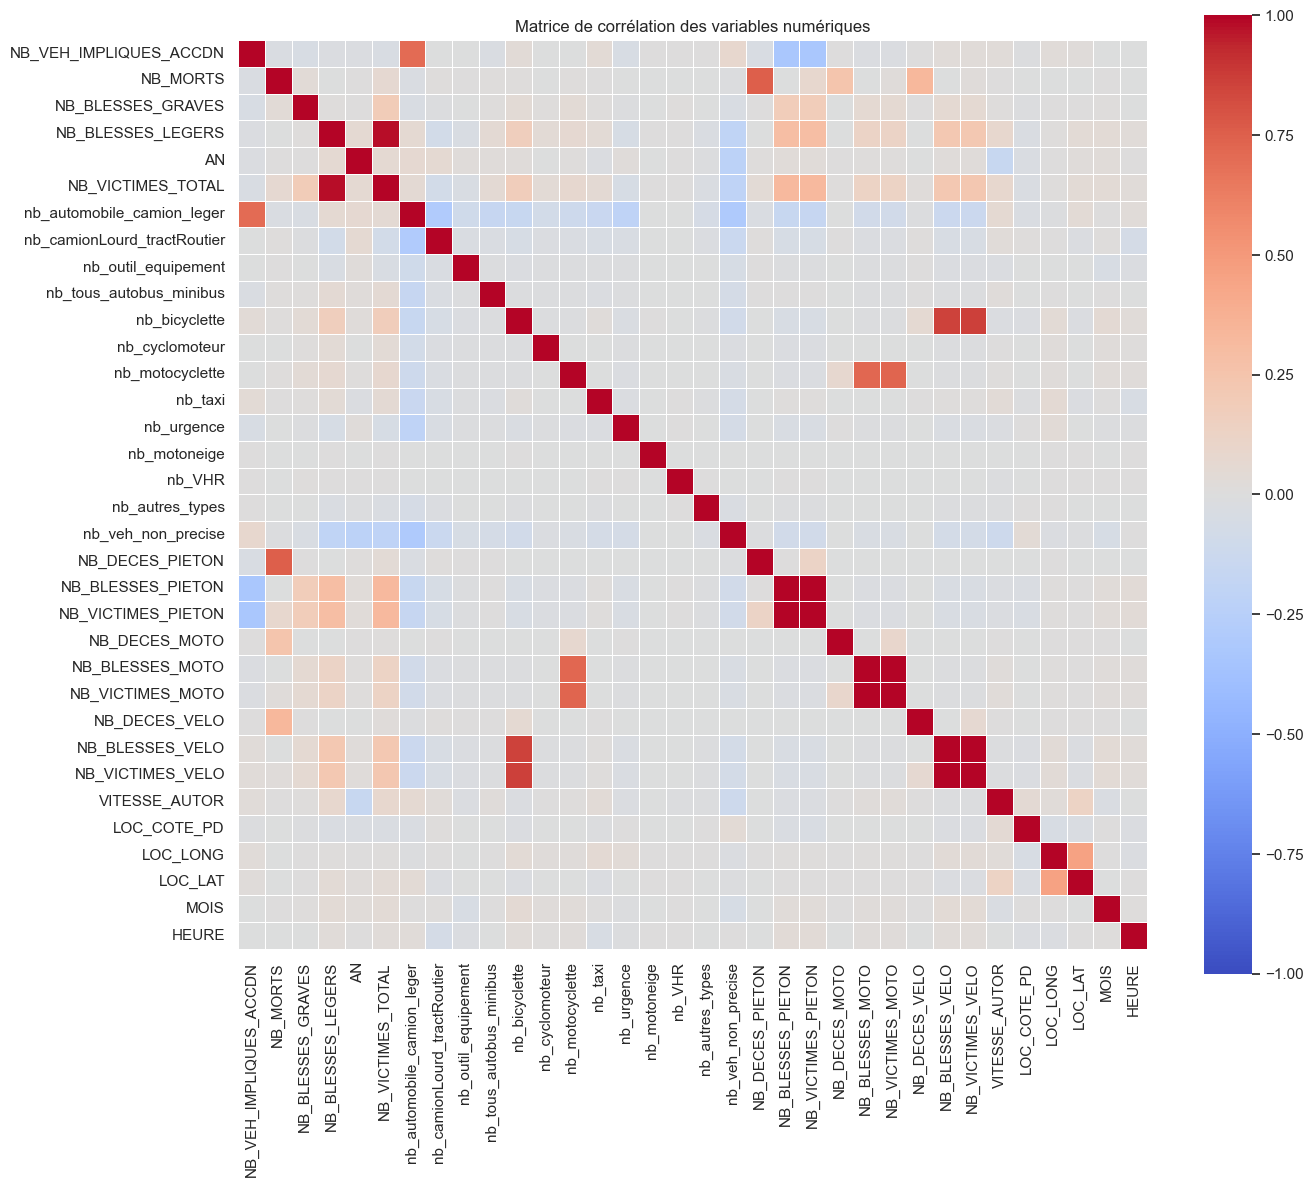

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax, 
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation des variables numériques')
plt.tight_layout()
plt.show()

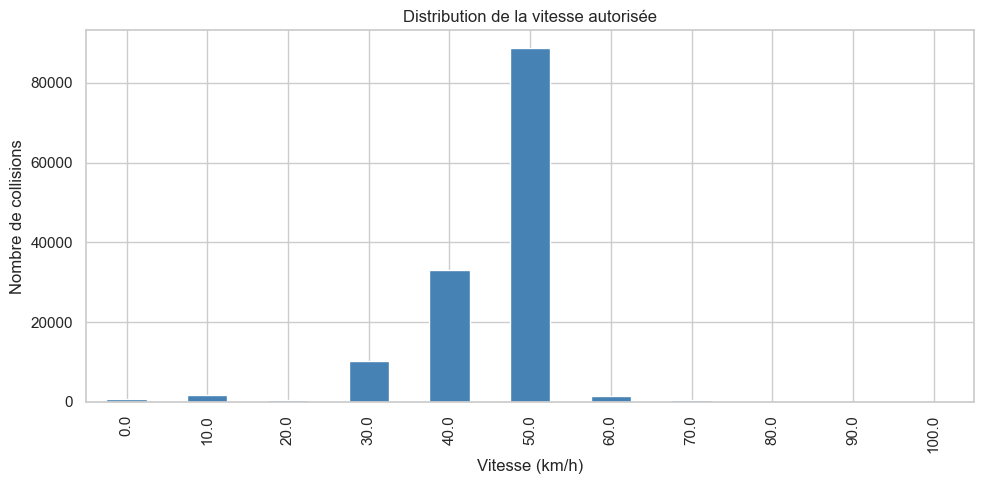

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
df['VITESSE_AUTOR'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue')
ax.set_title('Distribution de la vitesse autorisée')
ax.set_xlabel('Vitesse (km/h)')
ax.set_ylabel('Nombre de collisions')
plt.tight_layout()
plt.show()

### Pour le graphique précédent, c'est normal s'il n'y a aucune collisions avec une vitesse autorisée de 100km/h, en fait il est précisé sur le site de la ville que le jeu de donnée est sur le réseau routier de l'Agglomération de Montréal (exclusion des collisions survenues sur le réseau autoroutier)